In [2]:
# Module 2 - Analytics Pipeline

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

import joblib

sns.set_theme(style="whitegrid")

# Load Titanic ONCE
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.info()
display(df.describe(include="all"))

# Missing-value percentages
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing value percentages:")
display(missing)

# Offline fallback
df.to_csv("titanic.csv", index=False)

print("\ntitanic.csv saved successfully.")

Dataset loaded successfully.
Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing value percentages:


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467



titanic.csv saved successfully.


In [4]:
# Missing-value handling

df_clean = df.copy()

print("Missing percentages before cleaning:")
display((df_clean.isnull().mean() * 100).sort_values(ascending=False))

# Under 5% missing -> drop affected rows
for col in ["embarked", "embark_town"]:
    if col in df_clean.columns:
        missing_pct = df_clean[col].isnull().mean() * 100
        if 0 < missing_pct < 5:
            df_clean = df_clean.dropna(subset=[col])
            print(f"{col}: {missing_pct:.2f}% missing -> dropped affected rows")

# 5%–30% missing -> median imputation for numeric age
if "age" in df_clean.columns:
    age_pct = df_clean["age"].isnull().mean() * 100
    if 5 <= age_pct <= 30:
        df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
        print(f"age: {age_pct:.2f}% missing -> median imputation")

# More than 30% missing -> encode as "Missing"
if "deck" in df_clean.columns:
    deck_pct = df_clean["deck"].isnull().mean() * 100
    if deck_pct > 30:
        df_clean["deck"] = df_clean["deck"].astype("object").fillna("Missing")
        print(f"deck: {deck_pct:.2f}% missing -> encoded as 'Missing' category")

print("\nRemaining missing values:")
display(df_clean.isnull().sum())

print("\nCleaned shape:", df_clean.shape)

Missing percentages before cleaning:


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467
sex,0.000000
pclass,0.000000
survived,0.000000
fare,0.000000
parch,0.000000
sibsp,0.000000


embarked: 0.22% missing -> dropped affected rows
age: 19.91% missing -> median imputation
deck: 77.39% missing -> encoded as 'Missing' category

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0



Cleaned shape: (889, 15)


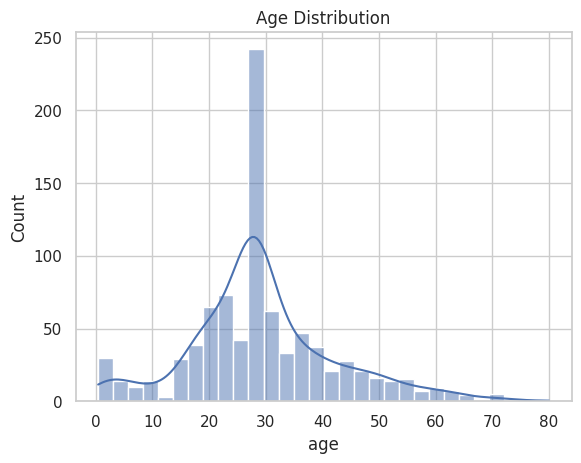

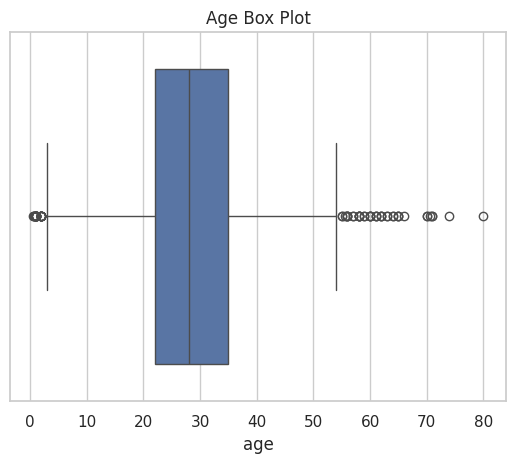

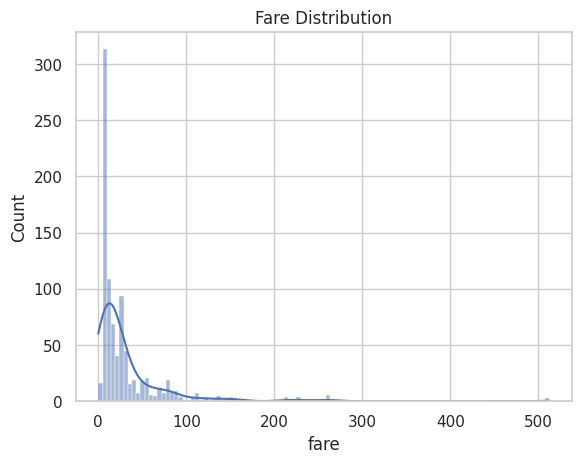

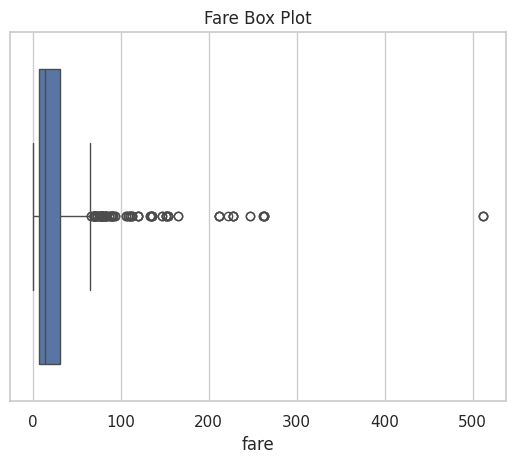

Age outliers: 65
Fare outliers: 114

Fare statistics
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Fare distribution is right-skewed.


In [5]:
# Histograms and box plots for age and fare

fig, ax = plt.subplots()
sns.histplot(df_clean["age"], kde=True, ax=ax)
ax.set_title("Age Distribution")
plt.show()

fig, ax = plt.subplots()
sns.boxplot(x=df_clean["age"], ax=ax)
ax.set_title("Age Box Plot")
plt.show()

fig, ax = plt.subplots()
sns.histplot(df_clean["fare"], kde=True, ax=ax)
ax.set_title("Fare Distribution")
plt.show()

fig, ax = plt.subplots()
sns.boxplot(x=df_clean["fare"], ax=ax)
ax.set_title("Fare Box Plot")
plt.show()


def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

age_outliers, age_low, age_high = iqr_outliers(df_clean["age"])
fare_outliers, fare_low, fare_high = iqr_outliers(df_clean["fare"])

print("Age outliers:", age_outliers)
print("Fare outliers:", fare_outliers)

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("\nFare statistics")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)

if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed.")
else:
    print("Fare distribution is approximately symmetric.")

In [6]:
# Survival rates

print("Survival rate by sex:")
display(df_clean.groupby("sex")["survived"].mean())

print("\nSurvival rate by passenger class:")
display(df_clean.groupby("pclass")["survived"].mean())

print("\nSurvival rate by sex and passenger class:")
display(
    df_clean.groupby(["sex", "pclass"])["survived"].mean()
)

# Boolean masking examples
female_first = df_clean[(df_clean["sex"] == "female") & (df_clean["pclass"] == 1)]
male_third = df_clean[(df_clean["sex"] == "male") & (df_clean["pclass"] == 3)]

print("\nFemale + First Class survival rate:",
      female_first["survived"].mean())

print("Male + Third Class survival rate:",
      male_third["survived"].mean())

Survival rate by sex:


,survived
sex,
female,0.740385
male,0.188908



Survival rate by passenger class:


,survived
pclass,
1,0.626168
2,0.472826
3,0.242363



Survival rate by sex and passenger class:


sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


Female + First Class survival rate: 0.967391304347826
Male + Third Class survival rate: 0.13544668587896252


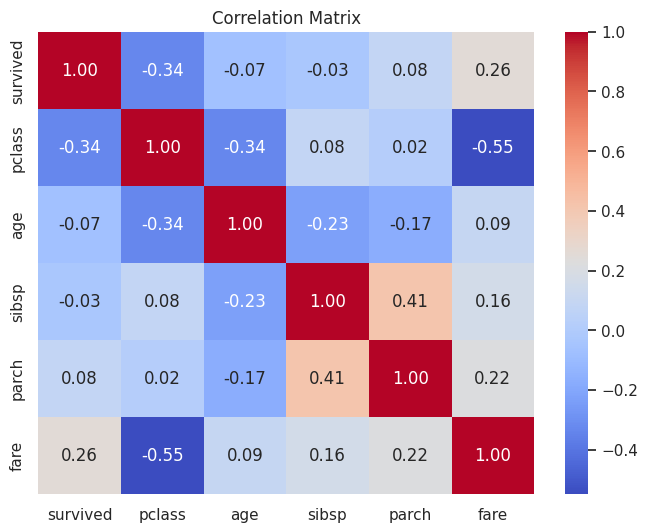

Two strongest correlations:
pclass vs fare: correlation = -0.548
sibsp vs parch: correlation = 0.415


In [7]:
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Find two strongest off-diagonal correlations
pairs = []

for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        pairs.append(
            (
                corr_cols[i],
                corr_cols[j],
                corr.iloc[i, j],
                abs(corr.iloc[i, j])
            )
        )

pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

print("Two strongest correlations:")
for p in pairs[:2]:
    print(f"{p[0]} vs {p[1]}: correlation = {p[2]:.3f}")

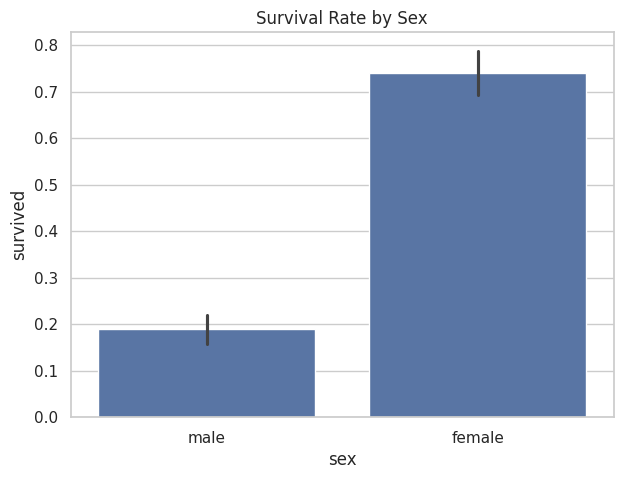

Interpretation: Females have a higher survival rate than males, showing a strong relationship between sex and survival.


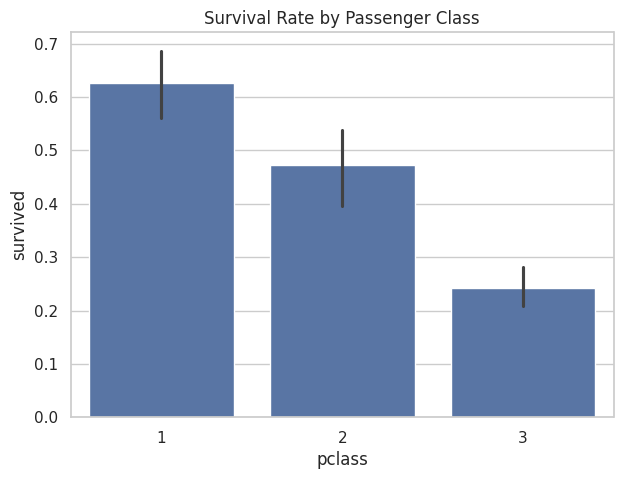

Interpretation: First-class passengers generally had higher survival rates than lower-class passengers.


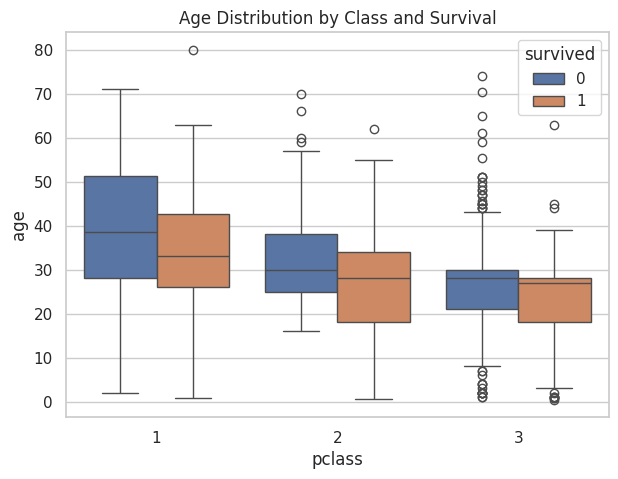

Interpretation: Age distributions differ across passenger classes, and survival also varies within those groups.


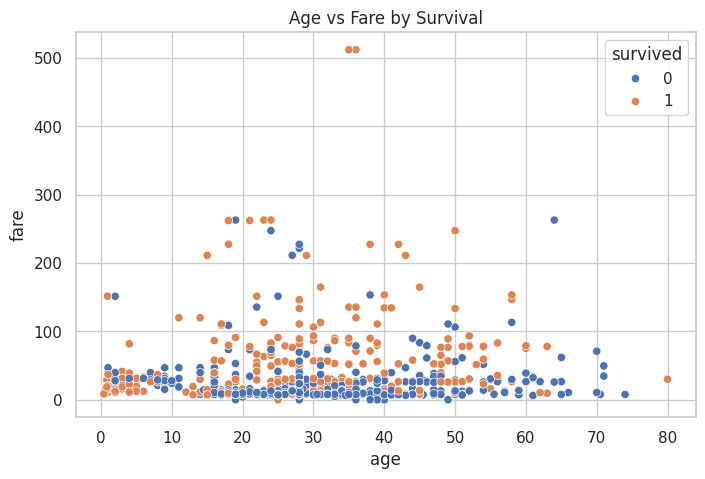

Interpretation: Fare and passenger characteristics show different patterns between survivors and non-survivors.


In [8]:
# Chart 1
plt.figure(figsize=(7, 5))
sns.barplot(data=df_clean, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.show()

print("Interpretation: Females have a higher survival rate than males, showing a strong relationship between sex and survival.")

# Chart 2
plt.figure(figsize=(7, 5))
sns.barplot(data=df_clean, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.show()

print("Interpretation: First-class passengers generally had higher survival rates than lower-class passengers.")

# Chart 3
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="pclass", y="age", hue="survived")
plt.title("Age Distribution by Class and Survival")
plt.show()

print("Interpretation: Age distributions differ across passenger classes, and survival also varies within those groups.")

# Chart 4
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="age", y="fare", hue="survived")
plt.title("Age vs Fare by Survival")
plt.show()

print("Interpretation: Fare and passenger characteristics show different patterns between survivors and non-survivors.")

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clean[["age_z", "fare_z"]] = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

print("Before:")
display(df_clean[["age", "fare"]].agg(["mean", "std"]))

print("\nAfter:")
display(df_clean[["age_z", "fare_z"]].agg(["mean", "std"]))

Before:


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504



After:


,age_z,fare_z
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00


In [10]:
# Prepare modeling data

model_df = df_clean.copy()

target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = model_df[features]
y = model_df[target]

# Stratified split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 7)
Testing shape: (178, 7)

Training class balance:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [11]:
# Prepare modeling data

model_df = df_clean.copy()

target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = model_df[features]
y = model_df[target]

# Stratified split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training shape: (711, 7)
Testing shape: (178, 7)

Training class balance:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [12]:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.769663,0.690141,0.720588,0.705036,0.754144
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914



 Logistic Regression
[[97 13]
 [21 47]]

 Decision Tree
[[88 22]
 [19 49]]

 Random Forest
[[96 14]
 [18 50]]


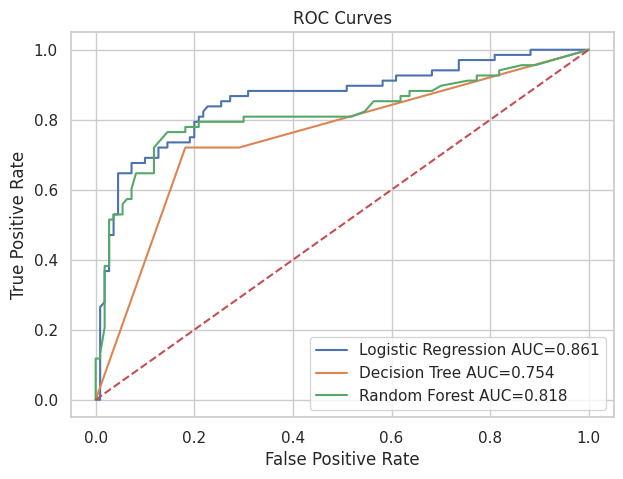

In [13]:
plt.figure(figsize=(7, 5))

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred)

    print("\n", name)
    print(cm)

    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc_score(y_test, prob):.3f}"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

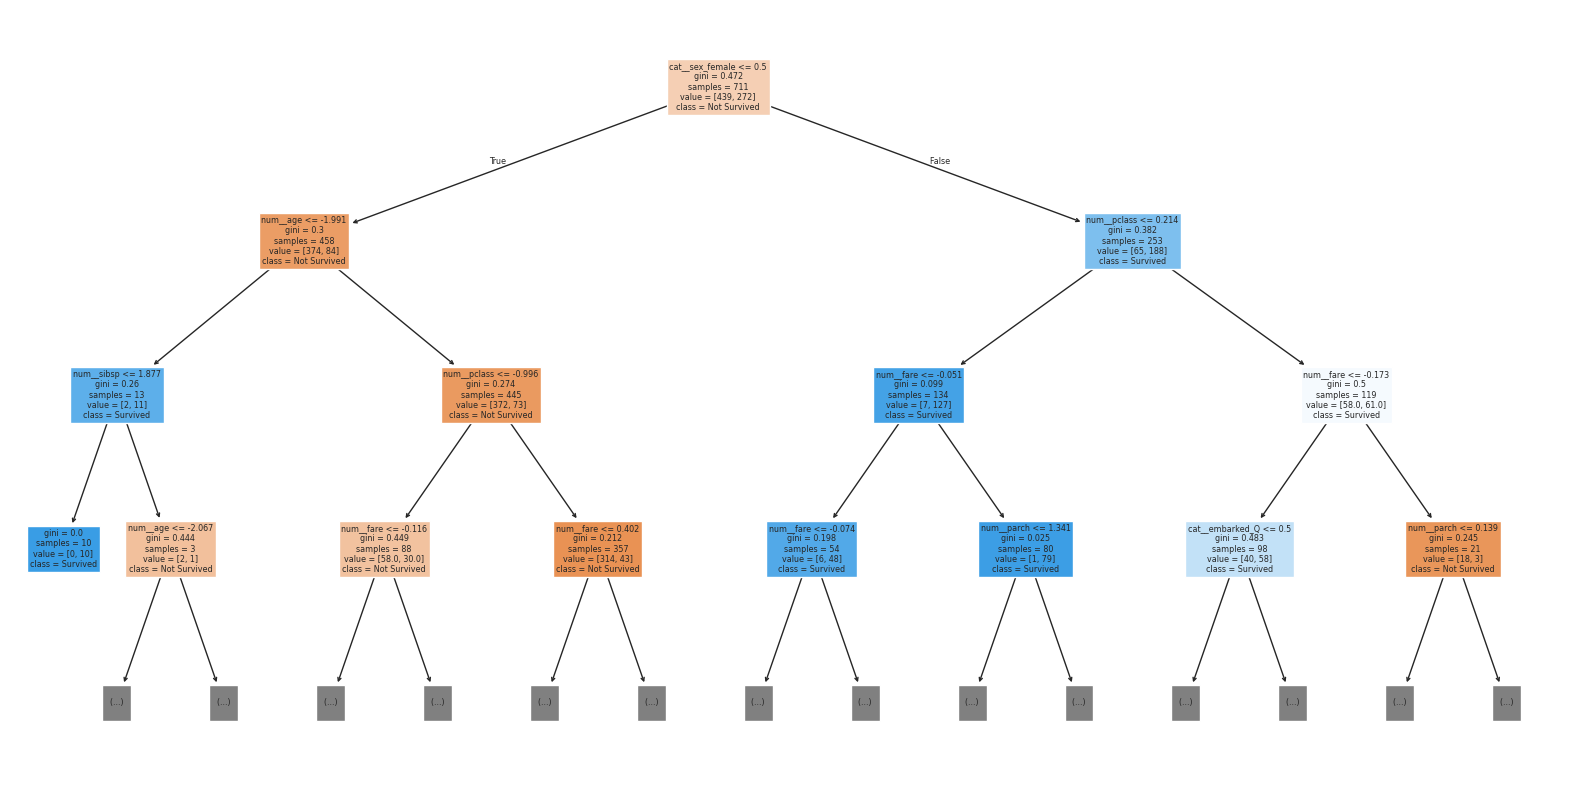

In [14]:
tree_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_pipe.fit(X_train, y_train)

feature_names = tree_pipe.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_pipe.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.show()

In [15]:
from imblearn.over_sampling import SMOTE

# Baseline
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

# Balanced
balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced.fit(X_train, y_train)
pred_bal = balanced.predict(X_test)

print("Class balance:")
print(y.value_counts())

print("\nBaseline:")
print(
    precision_score(y_test, pred_base),
    recall_score(y_test, pred_base),
    f1_score(y_test, pred_base)
)

print("\nBalanced:")
print(
    precision_score(y_test, pred_bal),
    recall_score(y_test, pred_bal),
    f1_score(y_test, pred_bal)
)

print("\nSMOTE note:")
print("SMOTE must be applied only to the training fold to avoid test-data leakage.")

Class balance:
survived
0    549
1    340
Name: count, dtype: int64

Baseline:
0.7833333333333333 0.6911764705882353 0.734375

Balanced:
0.7183098591549296 0.75 0.7338129496402878

SMOTE note:
SMOTE must be applied only to the training fold to avoid test-data leakage.


In [16]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

print("OOB Score:")
print(best_rf.named_steps["model"].oob_score_)

Best parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
OOB Score:
0.8213783403656821


MAE: 20.68667750309795
RMSE: 42.57063952837553
R2: 0.32072802913794685
Adjusted R2: 0.30502231882899766


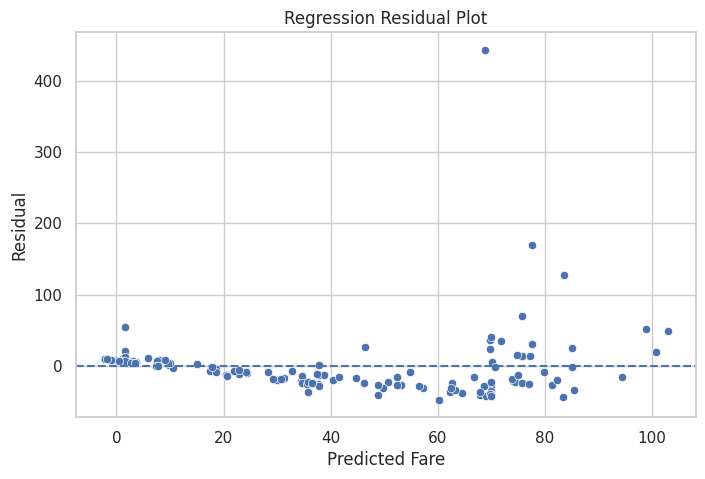

Interpretation: The residual plot is inspected for changing spread across predicted values; a visibly widening or narrowing spread would indicate heteroscedasticity.


In [17]:
# Predict fare using other available features

reg_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

X_reg = df_clean[reg_features]
y_reg = df_clean["fare"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

reg_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        LinearRegression()
    )
])

reg_pipe.fit(Xr_train, yr_train)

reg_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, reg_pred)
rmse = np.sqrt(mean_squared_error(yr_test, reg_pred))
r2 = r2_score(yr_test, reg_pred)

n = len(yr_test)
p = Xr_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

residuals = yr_test - reg_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=reg_pred, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Regression Residual Plot")
plt.show()

print("Interpretation: The residual plot is inspected for changing spread across predicted values; a visibly widening or narrowing spread would indicate heteroscedasticity.")

In [18]:
# Save the complete preprocessing + model pipeline

full_pipeline = best_rf

joblib.dump(full_pipeline, "model_pipeline.joblib")

print("Saved:", "model_pipeline.joblib")

# Reload
loaded_pipeline = joblib.load("model_pipeline.joblib")

# Test raw input
sample_prediction = loaded_pipeline.predict(X_test.head(5))

print("Reloaded pipeline predictions:")
print(sample_prediction)

Saved: model_pipeline.joblib
Reloaded pipeline predictions:
[0 0 0 0 0]


In [19]:
df_clean.to_csv("titanic.csv", index=False)

print("Saved titanic.csv")
print("Rows:", len(df_clean))

Saved titanic.csv
Rows: 889
